### Notes
Performing outlier removal on the data that it seems off
Current row 7, 15, 13 and 14 are not valid data points and should be removed.


### Outline on what to do

---

1. Dataset
    - Gunakan UBFC-Phys: memiliki dua kondisi (rest dan arithmetic task)

2. Ekstraksi Sinyal rPPG
    - Gunakan metode video-based rPPG (ICA/POS/CHROM/GREEN/OMIT)
    - Hasilkan estimasi Pulse Rate (HR) per detik

3. Validasi rPPG terhadap Ground Truth
    - Bandingkan HR dari rPPG dengan HR dari PPG (ground truth)

        Hitung:
        - Pearson correlation
        - MAE / RMSE

4. Analisis Perbedaan Kondisi (Rest vs Task)
    - Hitung HR rata-rata saat rest dan task per subjek

        Lakukan:

        - Paired test statistika untuk memastikan apakah peningkatan HR / HRV itu konsisten pada semua subjek

In [136]:
## Importing Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import neurokit2 as nk
import scipy
import os
from prettytable import PrettyTable

# List of signals and it's compsition
Rest (Task 1) / Mental Cognitive (Task 3) state:
- POS
- Green
- Chrom
- OMIT
- LGI


In [137]:
# def preprocess_ppg(signal, fs = 35):
#     """ Computes the Preprocessed PPG Signal, this steps include the following:
#         1. Moving Average Smoothing
#         2. Bandpass Filtering
        
#         Parameters:
#         ----------
#         signal (numpy array): 
#             The PPG Signal to be preprocessed
#         fs (float): 
#             The Sampling Frequency of the Signal
            
#         Returns:
#         --------
#         numpy array: 
#             The Preprocessed PPG Signal
    
#     """ 

#     # Bandpass filter to isolate the cardiac component (0.4-2.5 Hz)
#     b, a = scipy.signal.butter(3, [0.7, 2.5], btype='band', fs=fs)
#     filtered = scipy.signal.filtfilt(b, a, signal)

#     # Standarized filtered signal
#     filtered = (filtered - np.mean(filtered)) / np.std(filtered)
    
#     return filtered

In [138]:
def preprocess_ppg(signal, fs=35):
    # Bandpass filter
    b, a = scipy.signal.butter(3, [0.7, 2.5], btype='bandpass', fs=fs)
    filtered = scipy.signal.filtfilt(b, a, signal)

    # Normalize AFTER filtering
    filtered = (filtered - np.mean(filtered)) / np.std(filtered)
    return filtered


### Extracting the rPPG with the FaceDetector (Rest State)

---

In [139]:
root_path = "UBFC-Phys"
subjects = ["s41", "s42", "s43", "s44","s45","s46","s47","s48","s49","s50","s51","s52", "s53","s54","s55","s56"]
tasks = ["T1"]

sample_rate_gt = 64  # Hz
sample_rate_video = 35 # Hz

face_detector_gt_rest = []
pos_face_detector_rppg_data_rest = []
lgi_face_detector_rppg_data_rest = []
omit_face_detector_rppg_data_rest = []
green_face_detector_rppg_data_rest = []
chrom_face_detector_rppg_data_rest = []

for subject in subjects:
    for task in tasks:
        # Load ground truth data
        gt_file = os.path.join(root_path, subject, f"bvp_{subject}_{task}.csv")
        gt_data = pd.read_csv(gt_file, header=None).values.flatten()
        
        # Load rPPG data for each method
        pos_file = os.path.join(root_path, subject, f"{subject}_{task}_POS_rppg.npy")
        pos_data = np.load(pos_file)
        
        lgi_file = os.path.join(root_path, subject, f"{subject}_{task}_LGI_rppg.npy")
        lgi_data = np.load(lgi_file)

        omit_file = os.path.join(root_path, subject, f"{subject}_{task}_OMIT_rppg.npy")
        omit_data = np.load(omit_file)
        
        green_file = os.path.join(root_path, subject, f"{subject}_{task}_GREEN_rppg.npy")
        green_data = np.load(green_file)

        chrom_file = os.path.join(root_path, subject, f"{subject}_{task}_CHROM_rppg.npy")
        chrom_data = np.load(chrom_file)
        
        # Preprocess the rPPG signals
        gt_data_preprocessed = preprocess_ppg(gt_data, fs=sample_rate_gt)
        pos_data_preprocessed = preprocess_ppg(pos_data)
        lgi_data_preprocessed = preprocess_ppg(lgi_data)
        omit_data_preprocessed = preprocess_ppg(omit_data)
        green_data_preprocessed = preprocess_ppg(green_data)
        chrom_data_preprocessed = preprocess_ppg(chrom_data)
        
        # Store the data
        face_detector_gt_rest.append(gt_data_preprocessed)
        pos_face_detector_rppg_data_rest.append(pos_data_preprocessed)
        lgi_face_detector_rppg_data_rest.append(lgi_data_preprocessed)
        omit_face_detector_rppg_data_rest.append(omit_data_preprocessed)
        green_face_detector_rppg_data_rest.append(green_data_preprocessed)
        chrom_face_detector_rppg_data_rest.append(chrom_data_preprocessed)


In [140]:
# Print info about the list lengths
print(f"Number of GT arrays: {len(face_detector_gt_rest)}")
print(f"Number of POS arrays: {len(pos_face_detector_rppg_data_rest)}")

# Print shape of some individual arrays
print(f"First GT array shape: {face_detector_gt_rest[0].shape}")
print(f"First POS array shape: {pos_face_detector_rppg_data_rest[0].shape}")

Number of GT arrays: 16
Number of POS arrays: 16
First GT array shape: (11520,)
First POS array shape: (6325,)


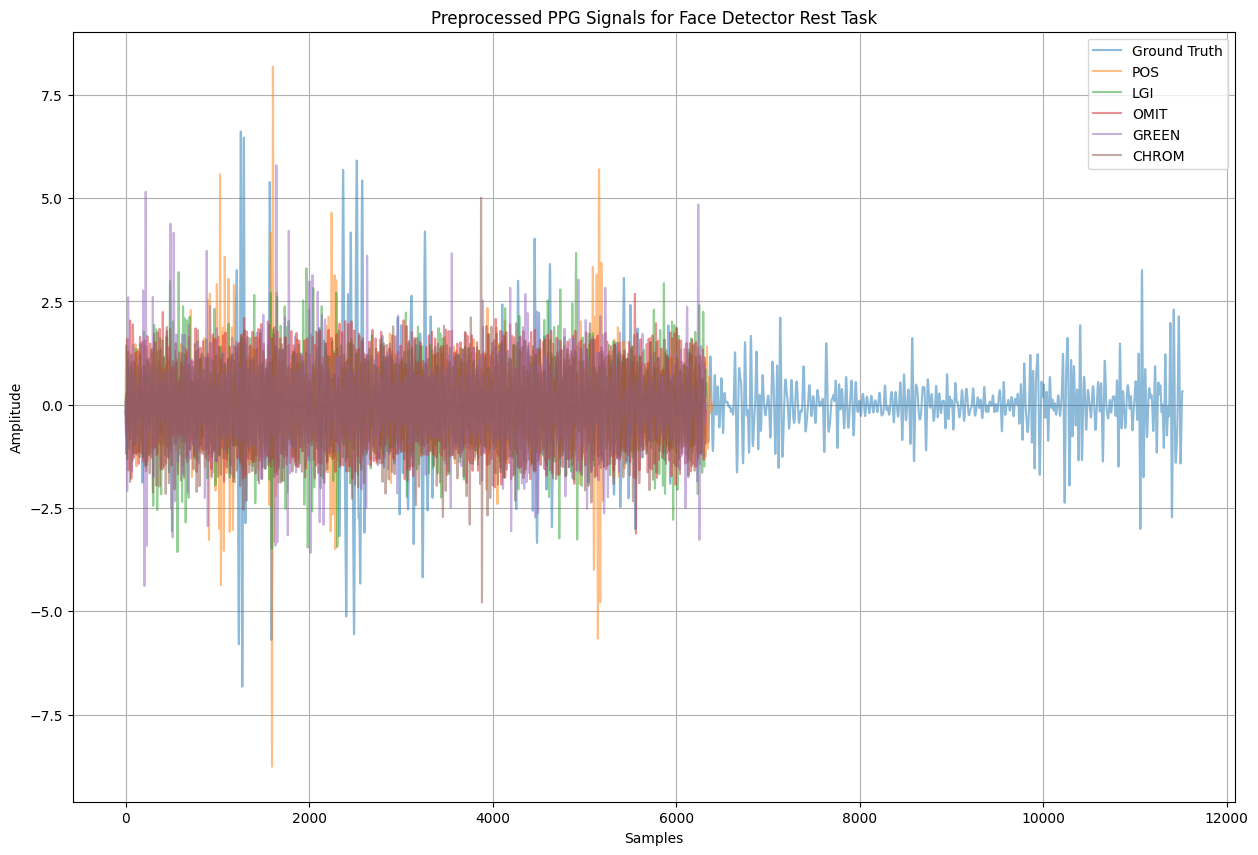

In [141]:
## Plot the Preprocessed Signals
plt.figure(figsize=(15, 10))
plt.plot(face_detector_gt_rest[15], label='Ground Truth', alpha=0.5)
plt.plot(pos_face_detector_rppg_data_rest[14], label='POS', alpha=0.5)
plt.plot(lgi_face_detector_rppg_data_rest[13], label='LGI', alpha=0.5)
plt.plot(omit_face_detector_rppg_data_rest[12], label='OMIT', alpha=0.5)
plt.plot(green_face_detector_rppg_data_rest[11], label='GREEN', alpha=0.5)
plt.plot(chrom_face_detector_rppg_data_rest[10], label='CHROM', alpha=0.5)
plt.title('Preprocessed PPG Signals for Face Detector Rest Task')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()

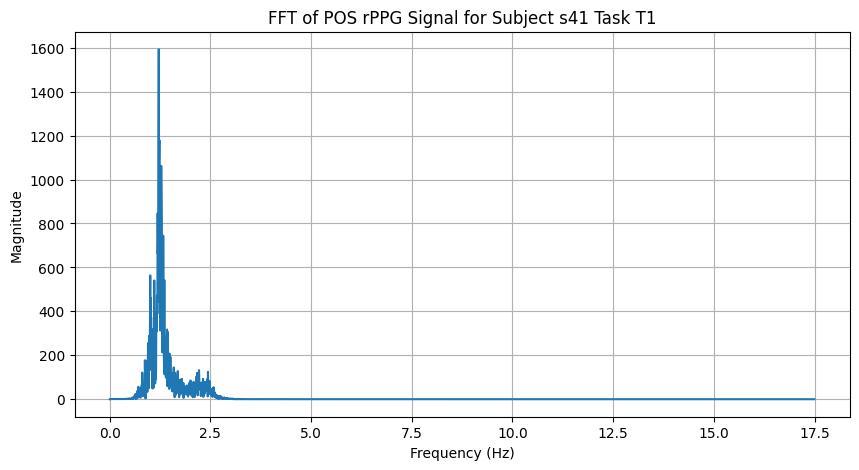

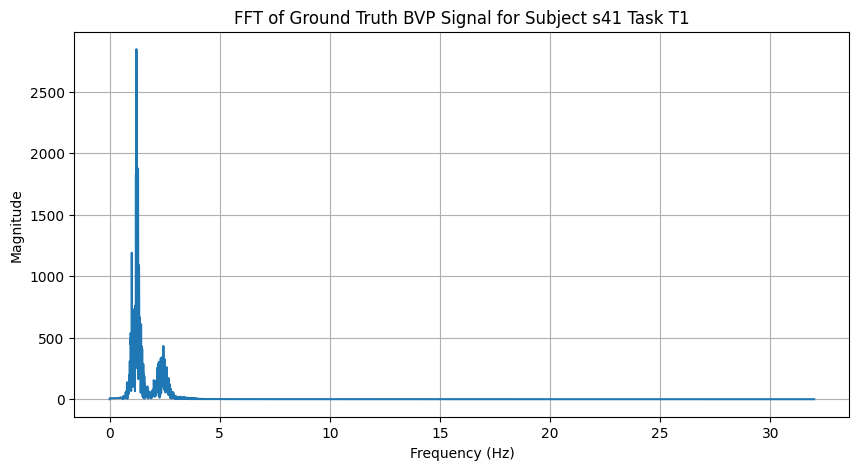

In [142]:
## Check the FFT of any signals if already being processed
def plot_fft(signal, fs, title):
    freqs = np.fft.fftfreq(len(signal), 1/fs)
    fft_values = np.abs(np.fft.fft(signal))
    
    plt.figure(figsize=(10, 5))
    plt.plot(freqs[:len(freqs)//2], fft_values[:len(fft_values)//2])
    plt.title(title)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.grid()
    plt.show()

# Example of plotting FFT for one of the rPPG methods
plot_fft(chrom_face_detector_rppg_data_rest[5], sample_rate_video, 'FFT of POS rPPG Signal for Subject s41 Task T1')
# Example of plotting FFT for ground truth BVP
plot_fft(face_detector_gt_rest[5], sample_rate_gt, 'FFT of Ground Truth BVP Signal for Subject s41 Task T1')

## Calculate the HR

---

In [143]:
def calculate_hr(gt, rppg):
    """ Calculate the Heart Rate from the Ground Truth and rPPG Signals
    
        Parameters:
        ----------
        gt (numpy array): 
            The Ground Truth BVP Signal
        rppg (numpy array): 
            The rPPG Signal
            
        Returns:
        --------
        float: 
            The calculated Heart Rate in beats per minute (BPM)
    """

    # Calculate the peaks in the ground truth signal
    gt_peaks, _ = scipy.signal.find_peaks(gt, prominence=0.5)  
    gt_hr = int(np.mean(60 / (np.diff(gt_peaks) / sample_rate_gt)))

    # Calculate the peaks in the rPPG signal
    rppg_peaks, _ = scipy.signal.find_peaks(rppg, prominence=0.5)  
    rppg_hr = int(np.mean(60 / (np.diff(rppg_peaks) / sample_rate_video)))

    return gt_hr, rppg_hr, gt_peaks, rppg_peaks



### Ekstraksi HR dari setiap metode

In [144]:
rppg = {
    "POS" : [],
    "LGI" : [],
    "OMIT" : [],
    "GREEN" : [],
    "CHROM" : []
}

for i in range(len(face_detector_gt_rest)):
    gt_hr, pos_hr, _, _ = calculate_hr(face_detector_gt_rest[i], pos_face_detector_rppg_data_rest[i])
    gt_hr, lgi_hr, _, _ = calculate_hr(face_detector_gt_rest[i], lgi_face_detector_rppg_data_rest[i])
    gt_hr, omit_hr, _, _ = calculate_hr(face_detector_gt_rest[i], omit_face_detector_rppg_data_rest[i])
    gt_hr, green_hr, _, _ = calculate_hr(face_detector_gt_rest[i], green_face_detector_rppg_data_rest[i])
    gt_hr, chrom_hr, _, _ = calculate_hr(face_detector_gt_rest[i], chrom_face_detector_rppg_data_rest[i])

    # Append the calculated heart rates to the rPPG dictionary
    rppg["POS"].append(pos_hr)
    rppg["LGI"].append(lgi_hr)
    rppg["OMIT"].append(omit_hr)
    rppg["GREEN"].append(green_hr)
    rppg["CHROM"].append(chrom_hr)

# Create a table to display the results
df = pd.DataFrame({
    "Subject": [f"s{i+41}" for i in range(len(face_detector_gt_rest))],
    "GT HR (BPM)": [calculate_hr(face_detector_gt_rest[i], face_detector_gt_rest[i])[0] for i in range(len(face_detector_gt_rest))],
    "POS HR (BPM)": rppg["POS"],
    "LGI HR (BPM)": rppg["LGI"],
    "OMIT HR (BPM)": rppg["OMIT"],
    "GREEN HR (BPM)": rppg["GREEN"],
    "CHROM HR (BPM)": rppg["CHROM"]
})

print("\nHeart Rate Results:")
print(df)




Heart Rate Results:
   Subject  GT HR (BPM)  POS HR (BPM)  LGI HR (BPM)  OMIT HR (BPM)  \
0      s41           97            97            97             97   
1      s42           71            72            72             72   
2      s43           95            95            94             94   
3      s44           65            71            66             66   
4      s45           78            77            77             77   
5      s46           75            74            74             74   
6      s47           78            78            80             80   
7      s48           68            73            72             72   
8      s49          101           102           101            101   
9      s50          103           103           103            103   
10     s51           63            63            63             63   
11     s52           84            91            91             91   
12     s53           65            88            89             89   

In [145]:
# Remove the row 7, 15, 13 and 14 from the dataFrame
df.drop([7, 15, 13, 14], inplace=True)
print(df)

   Subject  GT HR (BPM)  POS HR (BPM)  LGI HR (BPM)  OMIT HR (BPM)  \
0      s41           97            97            97             97   
1      s42           71            72            72             72   
2      s43           95            95            94             94   
3      s44           65            71            66             66   
4      s45           78            77            77             77   
5      s46           75            74            74             74   
6      s47           78            78            80             80   
8      s49          101           102           101            101   
9      s50          103           103           103            103   
10     s51           63            63            63             63   
11     s52           84            91            91             91   
12     s53           65            88            89             89   

    GREEN HR (BPM)  CHROM HR (BPM)  
0               93              96  
1              

In [146]:
# Compute the MAE 
from sklearn.metrics import mean_absolute_error
mae_pos = mean_absolute_error(np.array(df["GT HR (BPM)"]), np.array(df["POS HR (BPM)"]))
mae_lgi = mean_absolute_error(np.array(df["GT HR (BPM)"]), np.array(df["LGI HR (BPM)"]))
mae_omit = mean_absolute_error(np.array(df["GT HR (BPM)"]), np.array(df["OMIT HR (BPM)"]))
mae_green = mean_absolute_error(np.array(df["GT HR (BPM)"]), np.array(df["GREEN HR (BPM)"]))
mae_chrom = mean_absolute_error(np.array(df["GT HR (BPM)"]), np.array(df["CHROM HR (BPM)"]))

# Create a table to display the MAE results
df_mae = pd.DataFrame({
    "Method": ["POS", "LGI", "OMIT", "GREEN", "CHROM"],
    "MAE (BPM)": [mae_pos, mae_lgi, mae_omit, mae_green, mae_chrom]
})
print("\nMean Absolute Error (MAE) Results:")
print(df_mae)


Mean Absolute Error (MAE) Results:
  Method  MAE (BPM)
0    POS   3.333333
1    LGI   3.166667
2   OMIT   3.166667
3  GREEN   6.833333
4  CHROM   3.833333


In [147]:
## Calculate the RMSE 
from sklearn.metrics import root_mean_squared_error
rmse_pos = root_mean_squared_error(np.array(df["GT HR (BPM)"]), np.array(df["POS HR (BPM)"]))
rmse_lgi = root_mean_squared_error(np.array(df["GT HR (BPM)"]), np.array(df["LGI HR (BPM)"]))
rmse_omit = root_mean_squared_error(np.array(df["GT HR (BPM)"]), np.array(df["OMIT HR (BPM)"]))
rmse_green = root_mean_squared_error(np.array(df["GT HR (BPM)"]), np.array(df["GREEN HR (BPM)"]))
rmse_chrom = root_mean_squared_error(np.array(df["GT HR (BPM)"]), np.array(df["CHROM HR (BPM)"]))

# Create a table to display the RMSE results
df_rmse = pd.DataFrame({
    "Method": ["POS", "LGI", "OMIT", "GREEN", "CHROM"],
    "RMSE (BPM)": [rmse_pos, rmse_lgi, rmse_omit, rmse_green, rmse_chrom]
})
print("\nRoot Mean Squared Error (RMSE) Results:")
print(df_rmse)


Root Mean Squared Error (RMSE) Results:
  Method  RMSE (BPM)
0    POS    7.176350
1    LGI    7.268654
2   OMIT    7.268654
3  GREEN    8.962886
4  CHROM    7.505553


## Compute the HRV Metrics
HRV sendiri merupakan bagian detail dari denyut nadi / detak jantung, yang menunjukan pola variabilitas antara detak jantung.

Compute the correlation between the rPPG and PPG on several metrics and see which one is good

The HRV Metrics that we're going to use, all of the calculation is done under the
| **Domain**     | **HRV Feature** | **Unit** | **Description**                                                                 |
|----------------|------------------|----------|----------------------------------------------------------------------------------|
| **Time**       | MeanNN           | ms       | Mean NN interval (Time it takes between each peak to peak) in milis              |
|                | SDNN             | ms       | Standard deviation of the RR intervals                                           |
|                | RMSSD            | ms       | Root mean square of successive RR interval differences                           |
|                | PR               | bpm      | Mean heart rate                                                                  |
| **Frequency**  | LF               | ms²      | Power of low frequency band (0.04–0.15 Hz)                                       |
|                | HF               | ms²      | Power of high frequency band (0.15–0.4 Hz)                                       |
|                | LF/HF            | -        | Ratio of LF to HF                                                                |


### Experimental

In [148]:
# Compute the HRV metrics
gt_metrics = {
    'MeanNN': [],
    'SDNN': [],
    'RMSSD': [],
    'LF': [],
    'HF': [],
    'LF_HF': [],
    'PR' : [],
}

rppg_method = {
    "POS" : [],
    "LGI" : [],
    "OMIT" : [],
    "GREEN" : [],
    "CHROM" : []
}
 

for i in range(len(face_detector_gt_rest)): # 16 Subjects
    gt_hr, _, gt_peaks, _ = calculate_hr(face_detector_gt_rest[i], pos_face_detector_rppg_data_rest[i])
    gt_hrv = nk.hrv(gt_peaks, sampling_rate=sample_rate_gt)
    gt_metrics['PR'].append(gt_hr)
    gt_metrics['MeanNN'].append(gt_hrv['HRV_MeanNN'][0])
    gt_metrics['SDNN'].append(gt_hrv['HRV_SDNN'][0])
    gt_metrics['RMSSD'].append(gt_hrv['HRV_RMSSD'][0])
    gt_metrics['LF'].append(gt_hrv['HRV_LF'][0])
    gt_metrics['HF'].append(gt_hrv['HRV_HF'][0])
    gt_metrics['LF_HF'].append(gt_hrv['HRV_LFHF'][0])

    _, pos_hr, _, pos_peaks = calculate_hr(face_detector_gt_rest[i], pos_face_detector_rppg_data_rest[i])
    pos_hrv = nk.hrv(pos_peaks, sampling_rate=sample_rate_video)
    rppg_method['POS'].append({
        'PR': pos_hr,
        'MeanNN': pos_hrv['HRV_MeanNN'][0],
        'SDNN': pos_hrv['HRV_SDNN'][0],
        'RMSSD': pos_hrv['HRV_RMSSD'][0],
        'LF': pos_hrv['HRV_LF'][0],
        'HF': pos_hrv['HRV_HF'][0],
        'LF_HF': pos_hrv['HRV_LFHF'][0]
    })

    _, lgi_hr, _, lgi_peaks = calculate_hr(face_detector_gt_rest[i], lgi_face_detector_rppg_data_rest[i])
    lgi_hrv = nk.hrv(lgi_peaks, sampling_rate=sample_rate_video)
    rppg_method['LGI'].append({
        'PR': lgi_hr,
        'MeanNN': lgi_hrv['HRV_MeanNN'][0],
        'SDNN': lgi_hrv['HRV_SDNN'][0],
        'RMSSD': lgi_hrv['HRV_RMSSD'][0],
        'LF': lgi_hrv['HRV_LF'][0],
        'HF': lgi_hrv['HRV_HF'][0],
        'LF_HF': lgi_hrv['HRV_LFHF'][0]
    })

    _, omit_hr, _, omit_peaks = calculate_hr(face_detector_gt_rest[i], omit_face_detector_rppg_data_rest[i])
    omit_hrv = nk.hrv(omit_peaks, sampling_rate=sample_rate_video)
    rppg_method['OMIT'].append({
        'PR': omit_hr,  
        'MeanNN': omit_hrv['HRV_MeanNN'][0],
        'SDNN': omit_hrv['HRV_SDNN'][0],
        'RMSSD': omit_hrv['HRV_RMSSD'][0],
        'LF': omit_hrv['HRV_LF'][0],
        'HF': omit_hrv['HRV_HF'][0],
        'LF_HF': omit_hrv['HRV_LFHF'][0]
    })

    _, green_hr, _, green_peaks = calculate_hr(face_detector_gt_rest[i], green_face_detector_rppg_data_rest[i])
    green_hrv = nk.hrv(green_peaks, sampling_rate=sample_rate_video)
    rppg_method['GREEN'].append({
        'PR': green_hr,
        'MeanNN': green_hrv['HRV_MeanNN'][0],
        'SDNN': green_hrv['HRV_SDNN'][0],
        'RMSSD': green_hrv['HRV_RMSSD'][0],
        'LF': green_hrv['HRV_LF'][0],
        'HF': green_hrv['HRV_HF'][0],
        'LF_HF': green_hrv['HRV_LFHF'][0]
    })

    _, chrom_hr, _, chrom_peaks = calculate_hr(face_detector_gt_rest[i], chrom_face_detector_rppg_data_rest[i])
    chrom_hrv = nk.hrv(chrom_peaks, sampling_rate=sample_rate_video)
    rppg_method['CHROM'].append({
        'PR': chrom_hr,
        'MeanNN': chrom_hrv['HRV_MeanNN'][0],
        'SDNN': chrom_hrv['HRV_SDNN'][0],
        'RMSSD': chrom_hrv['HRV_RMSSD'][0],
        'LF': chrom_hrv['HRV_LF'][0],
        'HF': chrom_hrv['HRV_HF'][0],
        'LF_HF': chrom_hrv['HRV_LFHF'][0]
    })

print("\nGround Truth HRV Metrics:")
gt_metrics_df = pd.DataFrame(gt_metrics)
print(gt_metrics_df)

# Print the POS
print("\nPOS rPPG HRV Metrics:")
pos_metrics_df = pd.DataFrame(rppg_method['POS'])
print(pos_metrics_df)

# Print the LGI
print("\nLGI rPPG HRV Metrics:")
lgi_metrics_df = pd.DataFrame(rppg_method['LGI'])
print(lgi_metrics_df)

# Print the OMIT
print("\nOMIT rPPG HRV Metrics:")
omit_metrics_df = pd.DataFrame(rppg_method['OMIT'])
print(omit_metrics_df)

# Print the GREEN
print("\nGREEN rPPG HRV Metrics:")
green_metrics_df = pd.DataFrame(rppg_method['GREEN'])
print(green_metrics_df)

# Print the CHROM
print("\nCHROM rPPG HRV Metrics:")
chrom_metrics_df = pd.DataFrame(rppg_method['CHROM'])
print(chrom_metrics_df)



c:\Users\ACER\miniconda3\envs\phyrexian\Lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:536: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(



Ground Truth HRV Metrics:
         MeanNN         SDNN        RMSSD        LF        HF      LF_HF   PR
0    619.647491    54.571791    64.093721  0.032985  0.029763   1.108262   97
1    852.827381   110.427924   128.210855  0.004646  0.007777   0.597437   71
2    631.272007    45.674779    53.830921  0.042099  0.047017   0.895397   95
3    949.322090   141.668356   149.396747  0.007087  0.006826   1.038361   65
4    776.086957   100.865391   145.780526  0.020359  0.045086   0.451568   78
5    804.091928    59.723539    58.922455  0.006988  0.037724   0.185252   75
6    775.568182    90.708443   104.007464  0.027300  0.016603   1.644280   78
7   1295.955882  1756.276736  2371.901152  0.008049  0.000130  62.074657   68
8    593.646523    44.157331    47.570627  0.030970  0.033272   0.930806  101
9    581.016640    28.626258    20.237388  0.036626  0.014336   2.554862  103
10   953.542781    80.759238    91.029351  0.016241  0.024696   0.657628   63
11   765.825321   190.815206    99.98

In [152]:
# Remove the row 7, 15, 13 and 14 from the GT HRV Metrics and the rPPG Metrics since it has the outlier
gt_metrics_df = gt_metrics_df.drop([7, 15, 13, 14])
pos_metrics_df = pos_metrics_df.drop([7, 15, 13, 14])
lgi_metrics_df = lgi_metrics_df.drop([7, 15, 13, 14])
omit_metrics_df = omit_metrics_df.drop([7, 15, 13, 14])
green_metrics_df = green_metrics_df.drop([7, 15, 13, 14])
chrom_metrics_df = chrom_metrics_df.drop([7, 15, 13, 14])

# Print the cleaned DataFrames
print("\nCleaned Ground Truth HRV Metrics:")
print(gt_metrics_df)
print("\nCleaned POS rPPG HRV Metrics:")
print(pos_metrics_df)       
print("\nCleaned LGI rPPG HRV Metrics:")
print(lgi_metrics_df)
print("\nCleaned OMIT rPPG HRV Metrics:")
print(omit_metrics_df)
print("\nCleaned GREEN rPPG HRV Metrics:")
print(green_metrics_df)
print("\nCleaned CHROM rPPG HRV Metrics:")
print(chrom_metrics_df)



Cleaned Ground Truth HRV Metrics:
        MeanNN        SDNN       RMSSD        LF        HF     LF_HF   PR
0   619.647491   54.571791   64.093721  0.032985  0.029763  1.108262   97
1   852.827381  110.427924  128.210855  0.004646  0.007777  0.597437   71
2   631.272007   45.674779   53.830921  0.042099  0.047017  0.895397   95
3   949.322090  141.668356  149.396747  0.007087  0.006826  1.038361   65
4   776.086957  100.865391  145.780526  0.020359  0.045086  0.451568   78
5   804.091928   59.723539   58.922455  0.006988  0.037724  0.185252   75
6   775.568182   90.708443  104.007464  0.027300  0.016603  1.644280   78
8   593.646523   44.157331   47.570627  0.030970  0.033272  0.930806  101
9   581.016640   28.626258   20.237388  0.036626  0.014336  2.554862  103
10  953.542781   80.759238   91.029351  0.016241  0.024696  0.657628   63
11  765.825321  190.815206   99.980718  0.002420  0.009149  0.264498   84
12  933.919271  114.362026  157.155426  0.044620  0.105812  0.421694   65

Cl

In [166]:
# ## Compute the MAE / RMSE for HRV Metrics
# from sklearn.metrics import mean_absolute_error, mean_squared_error
# def compute_mae_rmse(gt_metrics, rppg_metrics):
#     """ Computes the Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) for HRV Metrics
    
#         Parameters:
#         ----------
#         gt_metrics (DataFrame): 
#             The Ground Truth HRV Metrics
#         rppg_metrics (DataFrame): 
#             The rPPG HRV Metrics
            
#         Returns:
#         --------
#         DataFrame: 
#             A DataFrame containing the MAE and RMSE for each metric
#     """
    
#     metrics = ['MeanNN', 'SDNN', 'RMSSD', 'LF', 'HF', 'LF_HF']
#     results = []

#     for metric in metrics:
#         mae = mean_absolute_error(gt_metrics[metric], rppg_metrics[metric])
#         rmse = np.sqrt(mean_squared_error(gt_metrics[metric], rppg_metrics[metric]))
#         results.append({'Metric': metric, 'MAE': mae, 'RMSE': rmse})

#     return pd.DataFrame(results)

# # Compute the MAE and RMSE for POS
# pos_mae_rmse = compute_mae_rmse(gt_metrics_df, pos_metrics_df)
# print("\nPOS rPPG HRV Metrics MAE and RMSE:")
# print(pos_mae_rmse)

# # Compute the MAE and RMSE for LGI
# lgi_mae_rmse = compute_mae_rmse(gt_metrics_df, lgi_metrics_df)
# print("\nLGI rPPG HRV Metrics MAE and RMSE:")
# print(lgi_mae_rmse)

# # Compute the MAE and RMSE for OMIT
# omit_mae_rmse = compute_mae_rmse(gt_metrics_df, omit_metrics_df)
# print("\nOMIT rPPG HRV Metrics MAE and RMSE:")
# print(omit_mae_rmse)

# # Compute the MAE and RMSE for GREEN
# green_mae_rmse = compute_mae_rmse(gt_metrics_df, green_metrics_df)
# print("\nGREEN rPPG HRV Metrics MAE and RMSE:")
# print(green_mae_rmse)

# # Compute the MAE and RMSE for CHROM
# chrom_mae_rmse = compute_mae_rmse(gt_metrics_df, chrom_metrics_df)
# print("\nCHROM rPPG HRV Metrics MAE and RMSE:")
# print(chrom_mae_rmse)

# ## Compute the Pearson Correlation for each rPPG method
# def compute_correlation(gt_metrics, rppg_metrics):
#     """ Computes the Pearson correlation between Ground Truth HRV Metrics and rPPG HRV Metrics
    
#         Parameters:
#         ----------
#         gt_metrics (DataFrame): 
#             The Ground Truth HRV Metrics
#         rppg_metrics (DataFrame): 
#             The rPPG HRV Metrics
            
#         Returns:
#         --------
#         DataFrame: 
#             A DataFrame containing the Pearson correlation for each metric
#     """
    
#     metrics = ['MeanNN', 'SDNN', 'RMSSD', 'LF', 'HF', 'LF_HF', 'PR']
#     correlations = {}

#     for metric in metrics:
#         correlation = gt_metrics[metric].corr(rppg_metrics[metric])
#         correlations[metric] = correlation

#     return correlations

# # Compute the Pearson correlation for each rPPG method
# pearson_correlations = {}
# for method in rppg_method.keys():
#     pearson_correlations[method] = compute_correlation(gt_metrics_df, pd.DataFrame(rppg_method[method]))

# print("\nPearson Correlation Results:")
# pearson_correlation_df = pd.DataFrame(pearson_correlations).T
# pearson_correlation_df.columns = ['MeanNN', 'SDNN', 'RMSSD', 'LF', 'HF', 'LF_HF', 'PR']
# print(pearson_correlation_df)

## Compute the Correlation of the between the rPPG and PPG for HR and HRV

In [165]:
# Pearson Correlation between rPPG and PPG on several metrics
def compute_correlation(gt_metrics, rppg_metrics):
    """ Computes the Pearson correlation between ground truth metrics and rPPG metrics
    
        Parameters:
        ----------
        gt_metrics (dict): 
            The Ground Truth HRV Metrics
        rppg_metrics (dict): 
            The rPPG HRV Metrics
            
        Returns:
        --------
        dict: 
            A dictionary containing the Pearson correlation coefficients for each metric
    """
    correlations = {}
    for metric in gt_metrics.keys():
        correlations[metric] = scipy.stats.pearsonr(gt_metrics[metric], [r[metric] for r in rppg_metrics])[0]
    return correlations

# Compute the Pearson correlation for each rPPG method
pearson_correlations = {}
for method in rppg_method.keys():
    pearson_correlations[method] = compute_correlation(gt_metrics, rppg_method[method])
# Create a DataFrame to display the Pearson correlation results
pearson_correlation_df = pd.DataFrame(pearson_correlations).T
pearson_correlation_df.columns = ['MeanNN', 'SDNN', 'RMSSD', 'LF', 'HF', 'LF_HF', 'PR']
print("\nPearson Correlation between Ground Truth and rPPG Metrics:")
print(pearson_correlation_df)



Pearson Correlation between Ground Truth and rPPG Metrics:
         MeanNN      SDNN     RMSSD        LF        HF     LF_HF        PR
POS    0.723816  0.121318  0.112080  0.345679  0.015788  0.244965  0.892308
LGI    0.742763  0.307863  0.379899  0.262742 -0.073897  0.256487  0.891092
OMIT   0.740164  0.263664  0.320233  0.123068 -0.151350  0.378860  0.891092
GREEN  0.243941  0.084061  0.102721 -0.062606 -0.553754 -0.067249  0.613906
CHROM  0.744901  0.128051  0.185654  0.373126 -0.181911  0.190831  0.893553
